# Base del proyecto:
Este es un documento de partida para que puedan experimentar y entrenar su propios modelos, pueden generarse una copia y trabajar désde aquí, les recomiendo usar el material brindado más abajo, porfa una vez tengan su propio notebook guardenlo en sus propias ramas, De hecho GoogleColab les permite abrir el notebbok desde el github solo deben añadir el url o su usuario, siempre y cuando el repositorio sea público, lo cual si aplica para nuestro caso..

In [6]:
import kagglehub
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import cv2
import os

  ## 2. Descargar el dataset y localizar `Train`


In [2]:
# Descarga del dataset
print("Descargando el dataset desde Kaggle...")
ruta_base = Path(
    kagglehub.dataset_download("mstjebashazida/affectnet")
)

# Buscar automáticamente una carpeta llamada Train en lugar de depende de algo como archive(3)
carpetas_train = list(ruta_base.rglob("Train"))

if not carpetas_train:
    raise FileNotFoundError(
        f"No se encontró una carpeta 'Train' dentro de {ruta_base}"
    )

ruta_train = carpetas_train[0]

print("Ruta base:", ruta_base)
print("Ruta de entrenamiento:", ruta_train)





Descargando el dataset desde Kaggle...


100%|██████████| 324M/324M [00:02<00:00, 128MB/s]

Extracting files...


Ruta base: /root/.cache/kagglehub/datasets/mstjebashazida/affectnet/versions/1
Ruta de entrenamiento: /root/.cache/kagglehub/datasets/mstjebashazida/affectnet/versions/1/archive (3)/Train


## 3. Contar imágenes por emoción

esto permite conocer el tamaño del dataset y detectar si hay emociones más presentes que otras


In [3]:
#conteo de imágenes por emoción
import pandas as pd

extensiones_validas = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

conteo_clases = {}

for carpeta_clase in sorted(ruta_train.iterdir()):
    if carpeta_clase.is_dir():
        cantidad = sum(
            1
            for archivo in carpeta_clase.rglob("*")
            if archivo.is_file()
            #extraer la extensión del archvivo ".PNG"-> ".png" y luego la busca en el diccionario
            and archivo.suffix.lower() in extensiones_validas
        )

        conteo_clases[carpeta_clase.name] = cantidad

distribucion = pd.DataFrame(
    list(conteo_clases.items()),
    columns=["Emoción", "Cantidad"]
)

distribucion["Porcentaje"] = (
    distribucion["Cantidad"]
    / distribucion["Cantidad"].sum()
    * 100
)

distribucion = distribucion.sort_values(
    by="Cantidad",
    ascending=False
).reset_index(drop=True)

print("Total de imágenes:", distribucion["Cantidad"].sum())
display(distribucion)

Total de imágenes: 16108


,Emoción,Cantidad,Porcentaje
0,sad,3091,19.189223
1,neutral,2758,17.121927
2,happy,2340,14.526943
3,surprise,2119,13.154954
4,contempt,1559,9.678421
5,fear,1512,9.386640
6,anger,1500,9.312143
7,disgust,1229,7.629749


##4. revisar un posible desbalance y por consiguiente sesgo en el aprendizaje

In [4]:
cantidad_maxima = int(distribucion["Cantidad"].max())
cantidad_minima = int(distribucion["Cantidad"].min())

if cantidad_minima == 0:
    razon_desbalance = np.inf
else:
    razon_desbalance = cantidad_maxima / cantidad_minima

print("Clase con más imágenes:")
display(distribucion.head(1))

print("Clase con menos imágenes:")
display(distribucion.tail(1))

print(f"Relación entre la clase mayoritaria y la minoritaria: {razon_desbalance:.2f}:1")

if razon_desbalance >= 3:
    print("Advertencia: existe un desbalance considerable entre las clases.")
elif razon_desbalance >= 1.5:
    print("Observación: existe cierto desbalance y deberá vigilarse durante la evaluación.")
else:
    print("Las cantidades son relativamente similares entre clases.")

Clase con más imágenes:


,Emoción,Cantidad,Porcentaje
0,sad,3091,19.189223


Clase con menos imágenes:


,Emoción,Cantidad,Porcentaje
7,disgust,1229,7.629749


Relación entre la clase mayoritaria y la minoritaria: 2.52:1
Observación: existe cierto desbalance y deberá vigilarse durante la evaluación.


##5. Gráfica de la distribución de emociones


/tmp/ipykernel_5076/762568697.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0, 0.5, 'Porcentaje')

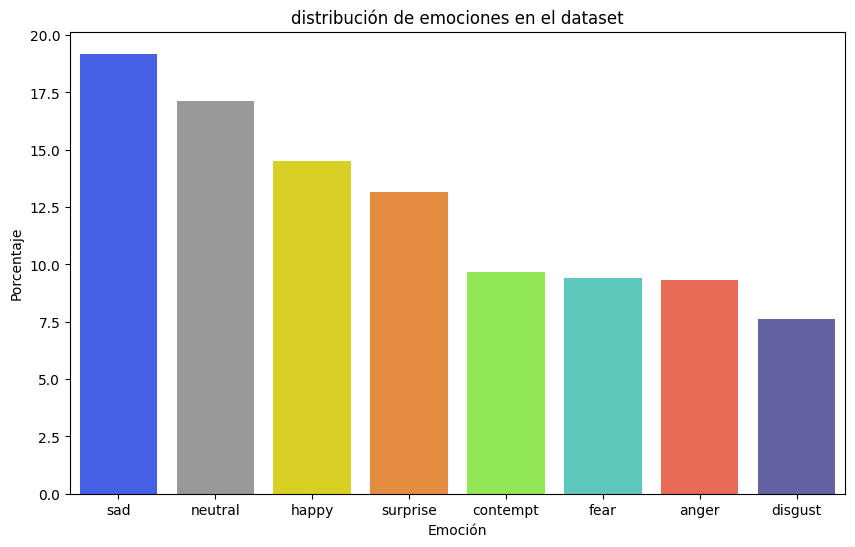

In [18]:
pallette = ["#2B4FFF", "#999999", "#F7EB07", "#FF8B26", "#8EFF3D", "#4CD9C8", "#FF5A3D", "#5B57AD"]


plt.figure(figsize=(10, 6))
sns.barplot(
    x="Emoción",
    y="Porcentaje",
    data=distribucion,
    palette=pallette
)

plt.title("distribución de emociones en el dataset")
plt.xlabel("Emoción")
plt.ylabel("Porcentaje")


##6. Carga de imágenes a tensorflow


In [ ]:
#Carga de imagenes a tensorflow
print("\nCargando imágenes en el pipeline de TensorFlow...")

# Keras requiere un tamaño inicial fijo para crear los tensores
dataset_crudo = tf.keras.utils.image_dataset_from_directory(
    ruta_train,
    image_size=(256, 256),
    batch_size=32,
    label_mode='categorical'
)


Cargando imágenes en el pipeline de TensorFlow...
Found 16108 files belonging to 8 classes.


##7. Visualización de las imagenes en 100*100 gray

Clases detectadas: ['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Procesando y graficando 25 ejemplos...


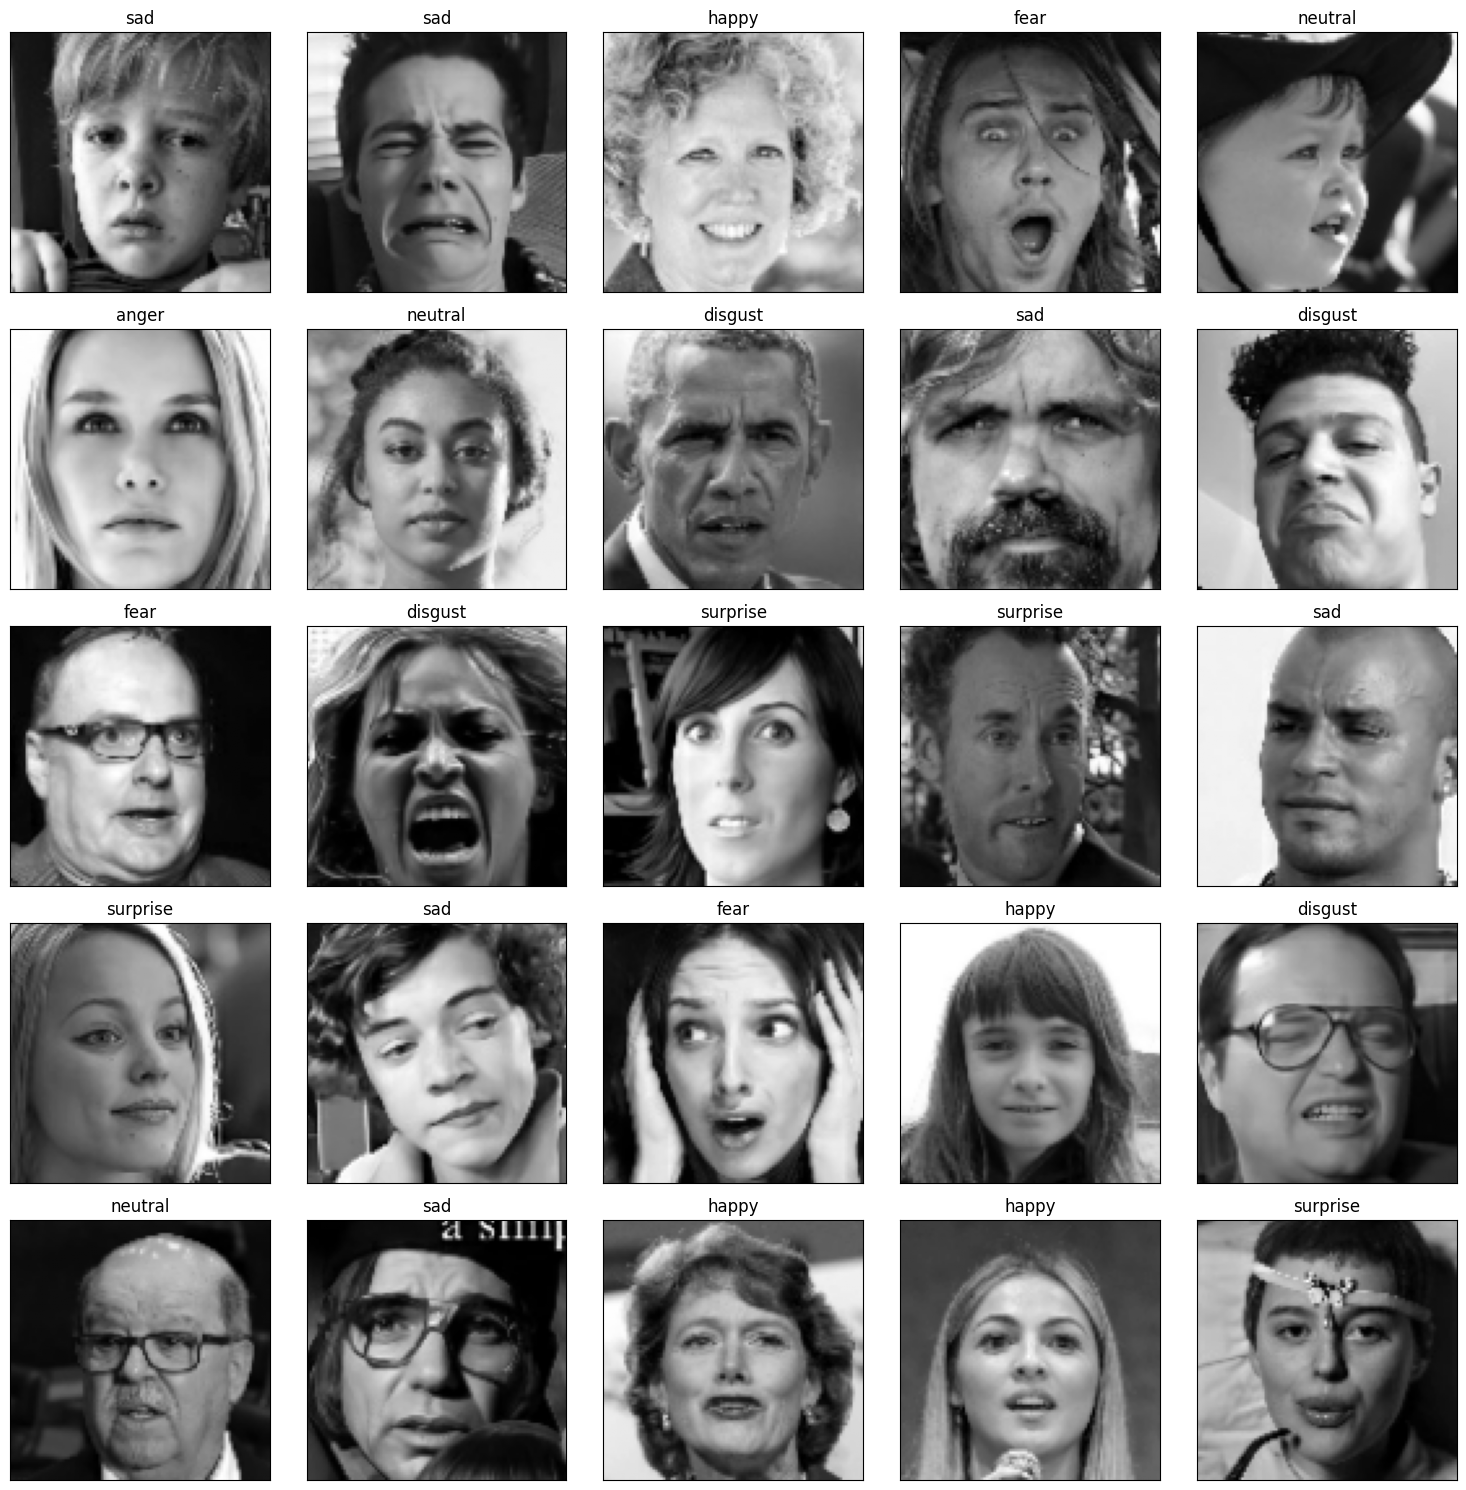

In [ ]:
# Inicializamos el diccionario
datos = {}

# .unbatch() rompe los bloques de 32 para que puedas iterar de 1 en 1
datos['train'] = dataset_crudo.unbatch()

# Extraemos los metadatos (los nombres de las emociones detectadas)
metadatos_clases = dataset_crudo.class_names
print("Clases detectadas:", metadatos_clases)

# Procesamiento de datos
print("\nProcesando y graficando 25 ejemplos...")

plt.figure(figsize=(15, 15))
TAMANO_IMG = 100 #este apartado lo pueden modificar a su gusto en caso de que quieran experimentar al respecto.

# Iteramos tomando exactamente 25 imágenes del pipeline
for i, (imagen, etiqueta) in enumerate(datos['train'].take(25)):

    # 1. Extraer el tensor y convertirlo a formato estándar de imagen (uint8)
    imagen_np = imagen.numpy().astype(np.uint8)

    # 2. Redimensionar a 100x100 usando OpenCV
    imagen_cv = cv2.resize(imagen_np, (TAMANO_IMG, TAMANO_IMG))

    # 3. Convertir de RGB a Escala de Grises
    imagen_cv = cv2.cvtColor(imagen_cv, cv2.COLOR_RGB2GRAY)

    # 4. Configurar la sub-gráfica en una cuadrícula de 5x5
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])

    # 5. Obtener la etiqueta (como usamos 'categorical', buscamos el índice del 1)
    indice_emocion = np.argmax(etiqueta.numpy())
    plt.title(metadatos_clases[indice_emocion])

    # 6. Mostrar la imagen en blanco y negro
    plt.imshow(imagen_cv, cmap='gray')

plt.tight_layout()
plt.show()

##8. Separación del dataset en training y testing (pendiente)

##9. Por definir